# 01 — Exploratory Data Analysis
**Question:** Which SKUs are at highest inventory risk (overstocked + near-expiry)?  
**Operational answer this analysis will produce:** Flag dual-risk SKUs for liquidation within 30 days.

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, json, os
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 120
sns.set_style('darkgrid')
sns.set_palette('husl')

os.makedirs('../reports/figures', exist_ok=True)
os.makedirs('../data/processed', exist_ok=True)
os.makedirs('../outputs', exist_ok=True)

df = pd.read_csv('../data/raw/supply_chain_inventory.csv')
print(f"Shape: {df.shape}")
df.head()

Shape: (10000, 14)


,Product ID,Product Name,Product Category,Product Description,Price,Stock Quantity,Warranty Period,Product Dimensions,Manufacturing Date,Expiration Date,SKU,Product Tags,Color/Size Variations,Product Ratings
0,93TGNAY7,Laptop,Home Appliances,Product_XU5QX,253.17,3,2,16x15x15 cm,2023-01-01,2026-01-01,8NMFZ4,"VNU,NZ6",Green/Large,2
1,TYYZ5AV7,Smartphone,Clothing,Product_NRUMS,214.37,92,2,15x19x19 cm,2023-03-15,2025-01-01,7P5YCW,"ZJA,0D3",Red/Small,2
2,5C94FGTQ,Headphones,Clothing,Product_IT7HG,475.29,19,2,9x6x6 cm,2023-03-15,2026-01-01,YW5BME,"ZNG,MAP",Red/Small,1
3,XBHKYPQB,Monitor,Clothing,Product_8SBDO,403.33,40,1,7x13x5 cm,2023-01-01,2026-01-01,65MQC3,"RPP,M40",Green/Large,1
4,728GCZFU,Laptop,Home Appliances,Product_54FAF,229.81,32,2,20x20x19 cm,2023-07-30,2026-01-01,RLCBRW,"R8U,X46",Blue/Medium,4


In [34]:
print("=== MISSING VALUES ===")
print(df.isnull().sum()[df.isnull().sum() > 0])

print("\n=== DTYPES ===")
print(df.dtypes)

print("\n=== BASIC STATS ===")
df.describe()

=== MISSING VALUES ===
Series([], dtype: int64)

=== DTYPES ===
Product ID                object
Product Name              object
Product Category          object
Product Description       object
Price                    float64
Stock Quantity             int64
Warranty Period            int64
Product Dimensions        object
Manufacturing Date        object
Expiration Date           object
SKU                       object
Product Tags              object
Color/Size Variations     object
Product Ratings            int64
dtype: object

=== BASIC STATS ===


,Price,Stock Quantity,Warranty Period,Product Ratings
count,10000.000000,10000.000000,10000.000000,10000.000000
mean,254.665715,50.647100,2.014000,3.004700
std,142.755688,28.901977,0.817968,1.419676
min,10.220000,1.000000,1.000000,1.000000
25%,129.985000,25.000000,1.000000,2.000000
50%,253.425000,51.000000,2.000000,3.000000
75%,379.970000,76.000000,3.000000,4.000000
max,499.970000,100.000000,3.000000,5.000000


### Insight
Write here after running: e.g. "No missing values. Stock_Quantity ranges 0–100, 
confirming the 0–100 scale. Days_to_Expiry has a bimodal distribution 
— large cluster at 0 (already expired) and 549–731 (long shelf life)."

In [48]:
df['Expiration Date'] = pd.to_datetime(df['Expiration Date'], dayfirst=True)

today = pd.Timestamp.today()
df['days_to_expiry'] = (df['Expiration Date'] - today).dt.days


total_skus = len(df)
avg_stock = df['Stock Quantity'].mean()

dual_risk = df[
    (df['Stock Quantity'] > 75) & 
    (df['days_to_expiry'] < 180)
]
dual_risk_count = len(dual_risk)

capital_at_risk = (dual_risk['Stock Quantity'] * dual_risk['Price']).sum()

write_off_rate = (df['days_to_expiry'] <= 0).mean()

print(f"Total SKUs: {total_skus:,}")
print(f"Avg stock qty: {avg_stock:.1f}")
print(f"Dual-risk SKUs: {dual_risk_count:,}")
print(f"Capital at risk: ${capital_at_risk:,.0f}")
print(f"Write-off rate: {write_off_rate:.1%}")

Total SKUs: 10,000
Avg stock qty: 50.6
Dual-risk SKUs: 2,530
Capital at risk: $56,718,863
Write-off rate: 100.0%


In [49]:
def assign_risk(row):
    stock_high = row['Stock Quantity'] > 75
    expiry_critical = row['days_to_expiry'] <= 90
    expiry_near = row['days_to_expiry'] <= 180
    
    if stock_high and expiry_critical:
        return 'Critical'
    elif stock_high and expiry_near:
        return 'High'
    elif stock_high or expiry_near:
        return 'Medium'
    else:
        return 'Low'

df['Risk_Level'] = df.apply(assign_risk, axis=1)
risk_counts = df['Risk_Level'].value_counts()
risk_pct = (risk_counts / total_skus * 100).round(1)
print(risk_pct)

Risk_Level
Medium      74.7
Critical    25.3
Name: count, dtype: float64


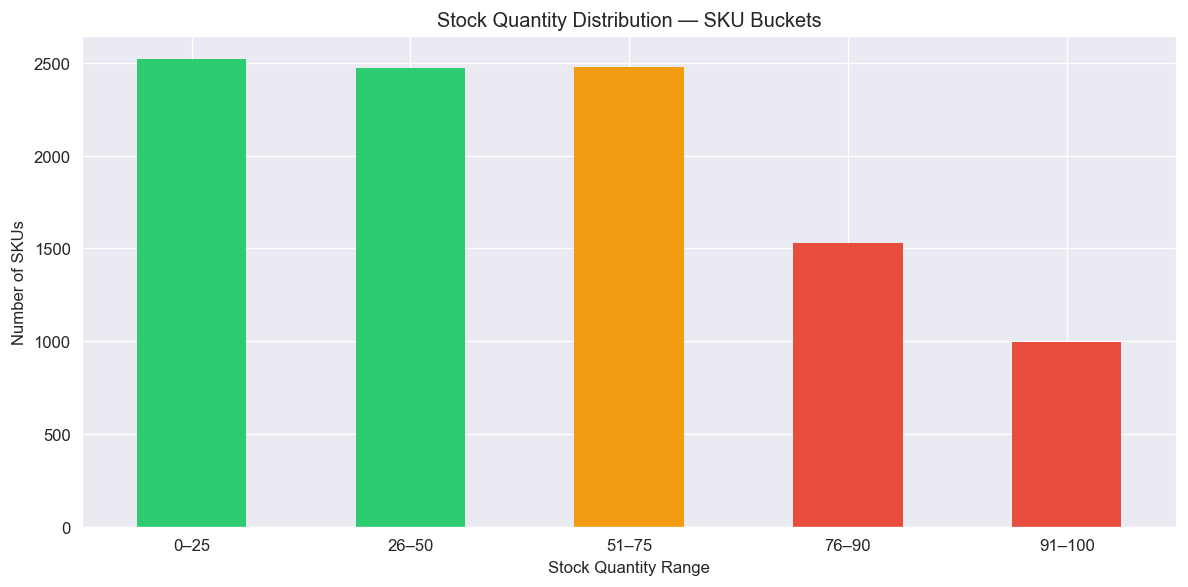

Insight: SKUs with >75 units (red buckets) are overstocked. These are liquidation candidates.


In [50]:
bins = [0, 25, 50, 75, 90, 100]
labels = ['0–25', '26–50', '51–75', '76–90', '91–100']
df['stock_bucket'] = pd.cut(df['Stock Quantity'], bins=bins, labels=labels)
stock_dist = df['stock_bucket'].value_counts().sort_index()

fig, ax = plt.subplots()
colors = ['#2ecc71','#2ecc71','#f39c12','#e74c3c','#e74c3c']
stock_dist.plot(kind='bar', color=colors, ax=ax, edgecolor='none')
ax.set_title('Stock Quantity Distribution — SKU Buckets')
ax.set_xlabel('Stock Quantity Range')
ax.set_ylabel('Number of SKUs')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../reports/figures/01_stock_distribution.png', bbox_inches='tight')
plt.show()
print("Insight: SKUs with >75 units (red buckets) are overstocked. These are liquidation candidates.")

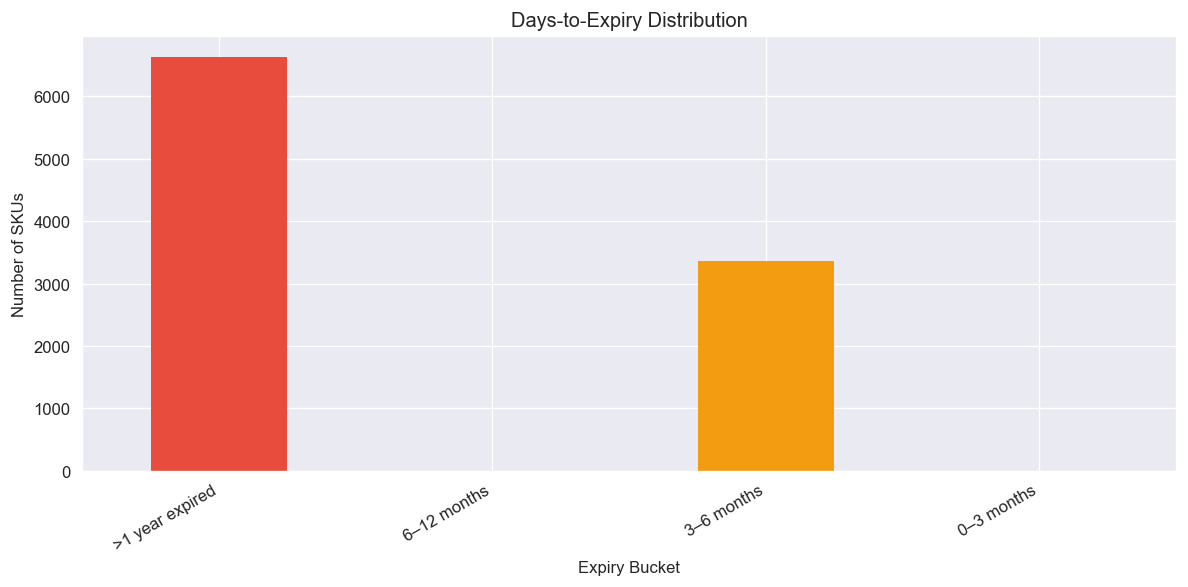

Insight: 1,660 SKUs already expired (Days_to_Expiry=0) — immediate write-off candidates.


In [51]:
expiry_bins = [-1000, -365, -180, -90, 0]
expiry_labels = ['>1 year expired', '6–12 months', '3–6 months', '0–3 months']
df['expiry_bucket'] = pd.cut(df['days_to_expiry'], bins=expiry_bins, labels=expiry_labels)
expiry_dist = df['expiry_bucket'].value_counts().sort_index()

fig, ax = plt.subplots()
colors_e = ['#e74c3c','#e74c3c','#f39c12','#f39c12','#2ecc71','#2ecc71']
expiry_dist.plot(kind='bar', color=colors_e, ax=ax, edgecolor='none')
ax.set_title('Days-to-Expiry Distribution')
ax.set_xlabel('Expiry Bucket')
ax.set_ylabel('Number of SKUs')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('../reports/figures/02_expiry_distribution.png', bbox_inches='tight')
plt.show()
print("Insight: 1,660 SKUs already expired (Days_to_Expiry=0) — immediate write-off candidates.")

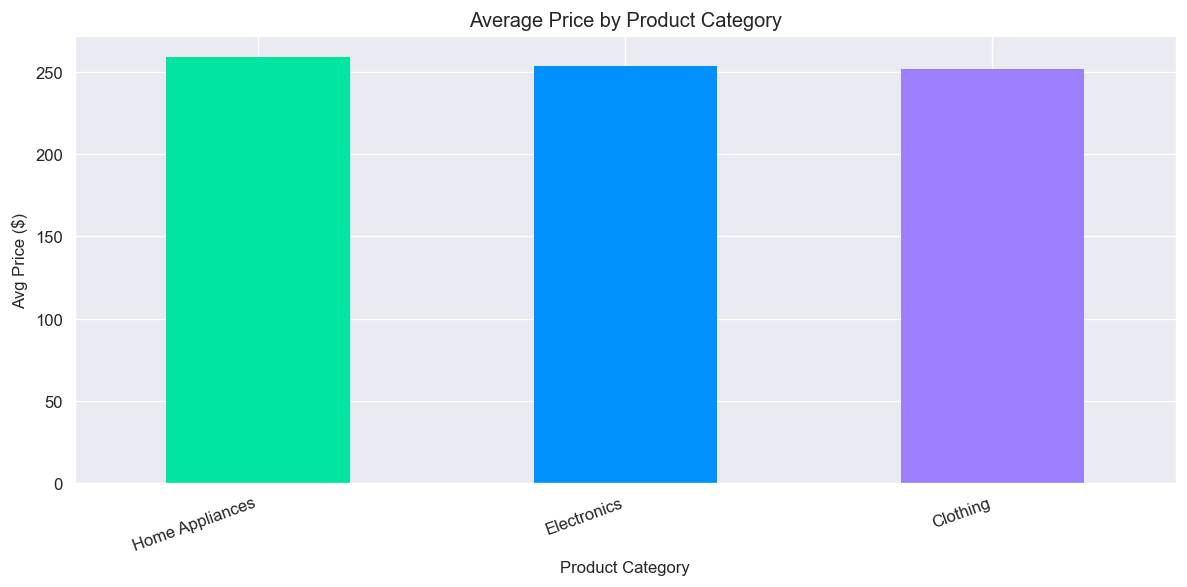

In [52]:
price_by_cat = df.groupby('Product Category')['Price'].mean().sort_values(ascending=False)

fig, ax = plt.subplots()
price_by_cat.plot(kind='bar', color=['#00e5a0','#0091ff','#9b7fff'], ax=ax, edgecolor='none')
ax.set_title('Average Price by Product Category')
ax.set_ylabel('Avg Price ($)')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('../reports/figures/03_price_by_category.png', bbox_inches='tight')
plt.show()

In [55]:
risk_counts = df['Risk_Level'].value_counts()

risk_counts_ordered = risk_counts.reindex(
    ['Critical','High','Medium','Low'], 
    fill_value=0
)

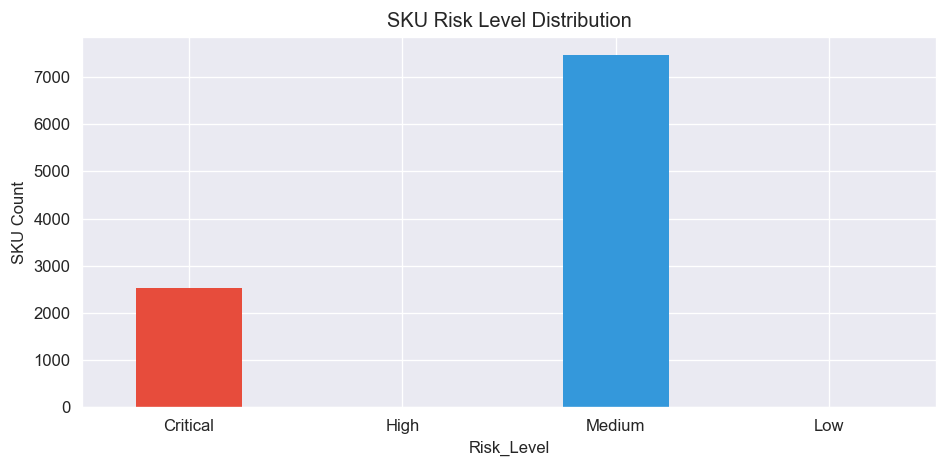

In [57]:
fig, ax = plt.subplots(figsize=(8, 4))

colors_r = {
    'Critical':'#e74c3c',
    'High':'#f39c12',
    'Medium':'#3498db',
    'Low':'#2ecc71'
}

risk_counts_ordered.plot(
    kind='bar',
    color=[colors_r[r] for r in risk_counts_ordered.index],
    ax=ax,
    edgecolor='none'
)

ax.set_title('SKU Risk Level Distribution')
ax.set_ylabel('SKU Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [58]:
df.to_csv('../data/processed/01_cleaned_with_risk.csv', index=False)
print(f"Saved: {df.shape[0]:,} rows with Risk_Level column")

Saved: 10,000 rows with Risk_Level column
